In [22]:
import sys
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.utils as vutils
import matplotlib.pyplot as plt

from tqdm import tqdm
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [23]:
PROJECT_ROOT = r"D:\PROJECT_ROOT"
DATASET_PATH = os.path.join(PROJECT_ROOT, "DATASET")
SRC_PATH = os.path.join(PROJECT_ROOT, "src")
MODELS_PATH = os.path.join(PROJECT_ROOT, "models")

os.makedirs(MODELS_PATH, exist_ok=True)

import sys
if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

In [24]:
from data_loader import get_dataloader

IMAGE_SIZE = 64
BATCH_SIZE = 32

dataloader, NUM_CLASSES, CLASS_NAMES = get_dataloader(
    DATASET_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

print("Classes:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)

Classes: ['Guava_Healthy', 'Guava_Unhealthy', 'Lemon', 'Lychee_Healthy', 'Lychee_Unhealthy', 'Mango_Unhealthy']
Number of classes: 6


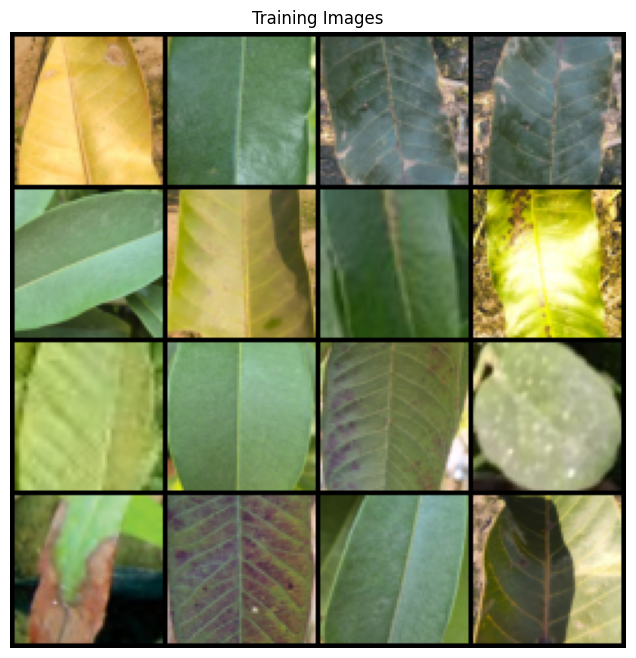

Labels: tensor([5, 3, 5, 5, 3, 5, 3, 5, 0, 3, 1, 2, 4, 1, 4, 5])


In [25]:
real_images, real_labels = next(iter(dataloader))

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(
    np.transpose(
        vutils.make_grid(real_images[:16], nrow=4, normalize=True),
        (1, 2, 0)
    )
)
plt.show()

print("Labels:", real_labels[:16])


In [26]:
from dcgan import Generator, Discriminator, weights_init
# GAN Hyperparameters
nz = 100      # Noise vector size
ngf = 64      # Generator feature maps
ndf = 64      # Discriminator feature maps
nc = 3        # RGB images
EPOCHS = 20
LR = 0.0002
BETA1 = 0.5
netG = Generator(nz, ngf, nc, NUM_CLASSES).to(device)
netD = Discriminator(nc, ndf, NUM_CLASSES, img_size=IMAGE_SIZE).to(device)

netG.apply(weights_init)
netD.apply(weights_init)

print(netG)
print(netD)
criterion = nn.BCELoss()

optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, 0.999))
fixed_noise = torch.randn(NUM_CLASSES, nz, 1, 1, device=device)
fixed_labels = torch.arange(NUM_CLASSES, device=device)


Generator(
  (label_emb): Embedding(6, 6)
  (net): Sequential(
    (0): ConvTranspose2d(106, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=

In [27]:
img_list = []
G_losses = []
D_losses = []

print("Starting Training...")

for epoch in range(EPOCHS):
    for i, (real_imgs, labels) in enumerate(tqdm(dataloader)):

        real_imgs = real_imgs.to(device)
        labels = labels.to(device)
        bsz = real_imgs.size(0)

        real_targets = torch.ones(bsz, device=device)
        fake_targets = torch.zeros(bsz, device=device)

     
        netD.zero_grad()

        out_real = netD(real_imgs, labels)
        loss_real = criterion(out_real, real_targets)

        noise = torch.randn(bsz, nz, 1, 1, device=device)
        fake_imgs = netG(noise, labels)

        out_fake = netD(fake_imgs.detach(), labels)
        loss_fake = criterion(out_fake, fake_targets)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizerD.step()

   
        netG.zero_grad()

        out_fake = netD(fake_imgs, labels)
        loss_G = criterion(out_fake, real_targets)

        loss_G.backward()
        optimizerG.step()

    print(f"[{epoch+1}/{EPOCHS}] Loss_D: {loss_D.item():.4f} Loss_G: {loss_G.item():.4f}")

    with torch.no_grad():
        fake = netG(fixed_noise, fixed_labels).detach().cpu()

    img_list.append(vutils.make_grid(fake, nrow=NUM_CLASSES, normalize=True))


Starting Training...


100%|██████████| 10/10 [00:07<00:00,  1.25it/s]


[1/20] Loss_D: 1.0858 Loss_G: 8.5619


100%|██████████| 10/10 [00:07<00:00,  1.31it/s]


[2/20] Loss_D: 0.2895 Loss_G: 4.2931


...

[18/20] Loss_D: 0.3304 Loss_G: 4.7036


100%|██████████| 10/10 [00:11<00:00,  1.13s/it]


[19/20] Loss_D: 1.9160 Loss_G: 3.8053


100%|██████████| 10/10 [00:10<00:00,  1.01s/it]

[20/20] Loss_D: 0.3974 Loss_G: 4.4625


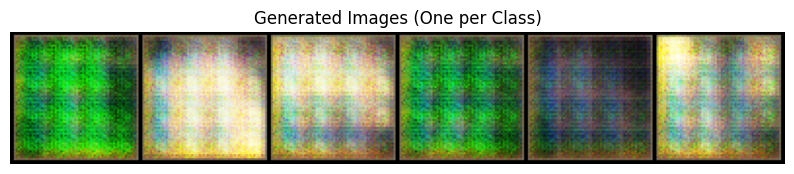

In [45]:
plt.figure(figsize=(10, 4))
plt.axis("off")
plt.title("Generated Images (One per Class)")
plt.imshow(np.transpose(img_list[-1], (1, 2, 0)))
plt.show()


In [46]:
torch.save(netG.state_dict(), os.path.join(MODELS_PATH, "netG_conditional.pth"))
torch.save(netD.state_dict(), os.path.join(MODELS_PATH, "netD_conditional.pth"))

print("Models saved successfully.")

Models saved successfully.


In [47]:
netD.eval()
for param in netD.parameters():
    param.requires_grad = False

In [48]:
from tqdm import tqdm

X_real = []
y_real = []

print("Extracting features from real images...")

with torch.no_grad():
    for imgs, labels in tqdm(dataloader):
        imgs = imgs.to(device)
        labels = labels.to(device)

        feats = netD.extract_features(imgs, labels)
        feats = feats.view(feats.size(0), -1)  # Flatten

        X_real.append(feats.cpu())
        y_real.append(labels.cpu())

X_real = torch.cat(X_real, dim=0).numpy()
y_real = torch.cat(y_real, dim=0).numpy()

print("Feature shape:", X_real.shape)
print("Labels shape:", y_real.shape)


Extracting features from real images...


  0%|          | 0/10 [00:00<?, ?it/s]C:\Users\Rupanshi\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 10/10 [00:07<00:00,  1.37it/s]

Feature shape: (302, 8192)
Labels shape: (302,)


In [32]:
from collections import Counter

print("Class distribution:")
for idx, count in Counter(y_real).items():
    print(f"{CLASS_NAMES[idx]}: {count}")


Class distribution:
Guava_Healthy: 50
Lemon: 53
Lychee_Healthy: 50
Lychee_Unhealthy: 50
Mango_Unhealthy: 49
Guava_Unhealthy: 50


In [33]:
TARGET_PER_CLASS = 100

X_syn = []
y_syn = []

print("Generating synthetic samples...")

for cls in range(NUM_CLASSES):
    current_count = (y_real == cls).sum()
    needed = TARGET_PER_CLASS - current_count

    if needed > 0:
        noise = torch.randn(needed, nz, 1, 1, device=device)
        labels = torch.full((needed,), cls, device=device, dtype=torch.long)

        with torch.no_grad():
            fake_imgs = netG(noise, labels)
            fake_feats = netD.extract_features(fake_imgs, labels)
            fake_feats = fake_feats.view(fake_feats.size(0), -1)

        X_syn.append(fake_feats.cpu().numpy())
        y_syn.append(labels.cpu().numpy())

        print(f"{CLASS_NAMES[cls]} → generated {needed} samples")


Generating synthetic samples...
Guava_Healthy → generated 50 samples
Guava_Unhealthy → generated 50 samples
Lemon → generated 47 samples
Lychee_Healthy → generated 50 samples
Lychee_Unhealthy → generated 50 samples
Mango_Unhealthy → generated 51 samples


In [34]:
if len(X_syn) > 0:
    X_syn = np.concatenate(X_syn, axis=0)
    y_syn = np.concatenate(y_syn, axis=0)

    X_balanced = np.concatenate([X_real, X_syn], axis=0)
    y_balanced = np.concatenate([y_real, y_syn], axis=0)
else:
    X_balanced = X_real
    y_balanced = y_real

print("Balanced feature shape:", X_balanced.shape)
print("Balanced label shape:", y_balanced.shape)


Balanced feature shape: (600, 8192)
Balanced label shape: (600,)


In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.2,
    stratify=y_balanced,
    random_state=42
)

In [50]:
from pilae3 import PILAE
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
Y_train_oh = encoder.fit_transform(y_train.reshape(-1, 1))

pilae = PILAE(input_dim=X_train.shape[1])
pilae.fit(X_train, Y_train_oh)


In [51]:
from sklearn.metrics import accuracy_score, classification_report

# Train accuracy
y_pred_train = pilae.predict(X_train)
train_acc = accuracy_score(y_train, y_pred_train)

# Test accuracy
y_pred_test = pilae.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, target_names=CLASS_NAMES))


Train Accuracy: 1.0000
Test Accuracy : 1.0000

Classification Report:
                  precision    recall  f1-score   support

   Guava_Healthy       1.00      1.00      1.00        20
 Guava_Unhealthy       1.00      1.00      1.00        20
           Lemon       1.00      1.00      1.00        20
  Lychee_Healthy       1.00      1.00      1.00        20
Lychee_Unhealthy       1.00      1.00      1.00        20
 Mango_Unhealthy       1.00      1.00      1.00        20

        accuracy                           1.00       120
       macro avg       1.00      1.00      1.00       120
    weighted avg       1.00      1.00      1.00       120



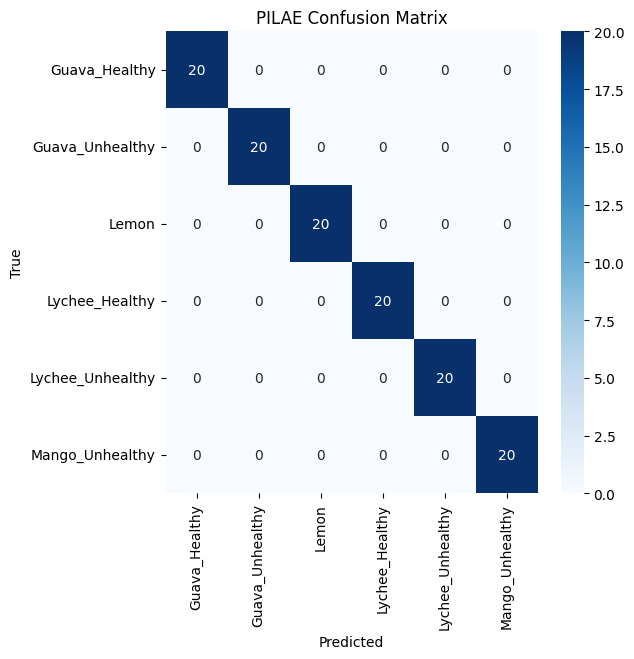

In [52]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("PILAE Confusion Matrix")
plt.show()


In [53]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_real,
    y_real,
    test_size=0.2,
    stratify=y_real,
    random_state=42
)

encoder = OneHotEncoder(sparse_output=False)
Y_train_r_oh = encoder.fit_transform(y_train_r.reshape(-1, 1))

pilae_real = PILAE(input_dim=X_train_r.shape[1])
pilae_real.fit(X_train_r, Y_train_r_oh)

y_pred_r = pilae_real.predict(X_test_r)

print("Real-only accuracy:", accuracy_score(y_test_r, y_pred_r))
print(classification_report(y_test_r, y_pred_r, target_names=CLASS_NAMES))


Real-only accuracy: 0.9836065573770492
                  precision    recall  f1-score   support

   Guava_Healthy       1.00      1.00      1.00        10
 Guava_Unhealthy       1.00      1.00      1.00        10
           Lemon       1.00      1.00      1.00        11
  Lychee_Healthy       0.91      1.00      0.95        10
Lychee_Unhealthy       1.00      0.90      0.95        10
 Mango_Unhealthy       1.00      1.00      1.00        10

        accuracy                           0.98        61
       macro avg       0.98      0.98      0.98        61
    weighted avg       0.99      0.98      0.98        61



In [55]:
from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_acc = []

for fold, (train_idx, test_idx) in enumerate(kfold.split(X_balanced, y_balanced)):
    X_tr, X_te = X_balanced[train_idx], X_balanced[test_idx]
    y_tr, y_te = y_balanced[train_idx], y_balanced[test_idx]

    enc = OneHotEncoder(sparse_output=False)
    Y_tr_oh = enc.fit_transform(y_tr.reshape(-1, 1))

    model = PILAE(input_dim=X_tr.shape[1])
    model.fit(X_tr, Y_tr_oh)

    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    fold_acc.append(acc)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")

print(f"\nMean Accuracy: {np.mean(fold_acc):.4f}")
print(f"Std Deviation: {np.std(fold_acc):.4f}")


Fold 1 Accuracy: 1.0000
Fold 2 Accuracy: 1.0000
Fold 3 Accuracy: 1.0000
Fold 4 Accuracy: 1.0000
Fold 5 Accuracy: 1.0000

Mean Accuracy: 1.0000
Std Deviation: 0.0000


In [56]:
gap = train_acc - test_acc
print("Accuracy gap:", gap)


Accuracy gap: 0.0


In [57]:
y_shuffled = np.random.permutation(y_balanced)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_balanced,
    y_shuffled,
    test_size=0.2,
    random_state=42
)

enc = OneHotEncoder(sparse_output=False)
Y_tr_oh = enc.fit_transform(y_tr.reshape(-1, 1))

model = PILAE(input_dim=X_tr.shape[1])
model.fit(X_tr, Y_tr_oh)

y_pred = model.predict(X_te)
print("Accuracy with shuffled labels:", accuracy_score(y_te, y_pred))


Accuracy with shuffled labels: 0.125


In [58]:
for test_cls in range(NUM_CLASSES):
    mask = y_balanced != test_cls

    X_tr = X_balanced[mask]
    y_tr = y_balanced[mask]

    X_te = X_balanced[~mask]
    y_te = y_balanced[~mask]

    enc = OneHotEncoder(sparse_output=False)
    Y_tr_oh = enc.fit_transform(y_tr.reshape(-1, 1))

    model = PILAE(input_dim=X_tr.shape[1])
    model.fit(X_tr, Y_tr_oh)

    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)

    print(f"Left-out class {CLASS_NAMES[test_cls]} accuracy: {acc:.4f}")


Left-out class Guava_Healthy accuracy: 0.1900
Left-out class Guava_Unhealthy accuracy: 0.0600
Left-out class Lemon accuracy: 0.4000
Left-out class Lychee_Healthy accuracy: 0.7900
Left-out class Lychee_Unhealthy accuracy: 0.2200
Left-out class Mango_Unhealthy accuracy: 0.0000
